In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
#import using polars
df = pl.read_csv(
    "/.../matches_ReDU_humans_cos07.tsv",
    separator="\t"
)
#keep only columns of interest
df_filtered = df[['USI', 'cosine_raw', 'precursor_mz', 'name', 'delta', 'delta_round', 
                  'ATTRIBUTE_DatasetAccession', 'UBERONBodyPartName'
                  ]]
#filter to kepep only matches with cosine similarity >= 0.7 and urine as the body part
df_filtered = df.filter(pl.col("cosine_raw") >= 0.7)
df_filtered = df_filtered.filter(pl.col("UBERONBodyPartName") == "urine")

#keep only columns of interest and drop duplicates
df_filtered2 = df_filtered[['USI', 'delta_round', 'ATTRIBUTE_DatasetAccession']]
df_filtered2 = df_filtered2.to_pandas()
df_filtered2 = df_filtered2.drop_duplicates()

In [3]:
#let's calculate the number of deltas per dataset
deltas_dataset = (
    df_filtered2.groupby("ATTRIBUTE_DatasetAccession")["delta_round"]
    .nunique()
    .reset_index(name="delta_round_count")
    .sort_values("delta_round_count", ascending=False)
)

deltas_dataset

,ATTRIBUTE_DatasetAccession,delta_round_count
4,MSV000084112,1244
0,MSV000082261,1214
9,MSV000096359,983
8,MSV000095726,871
6,MSV000090341,734
5,MSV000088255,422
11,MTBLS1465,298
7,MSV000090579,246
2,MSV000083538,208
12,MTBLS307,113


In [4]:
#let's calculate the number of scans per dataset
deltas_dataset = (
    df_filtered2.groupby("ATTRIBUTE_DatasetAccession")["USI"]
    .nunique()
    .reset_index(name="scans_count")
    .sort_values("scans_count", ascending=False)
)

deltas_dataset

,ATTRIBUTE_DatasetAccession,scans_count
9,MSV000096359,175038
8,MSV000095726,38508
4,MSV000084112,28060
0,MSV000082261,23396
7,MSV000090579,16532
6,MSV000090341,12168
5,MSV000088255,10595
1,MSV000082493,1849
2,MSV000083538,1072
12,MTBLS307,414


/tmp/ipykernel_3248352/3458952234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


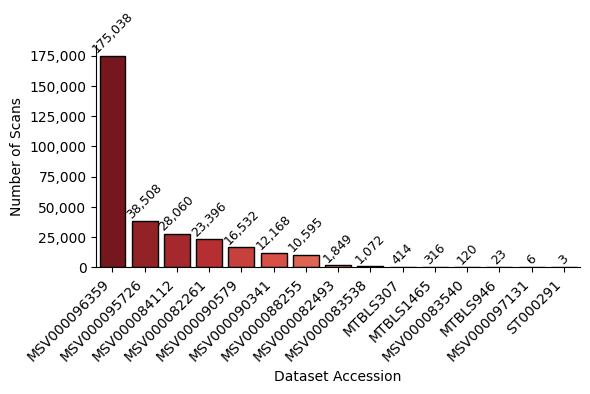

In [ ]:
# Plot
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    y='scans_count',
    x='ATTRIBUTE_DatasetAccession',
    data=deltas_dataset,
    palette='Reds_r',
    edgecolor='black',
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=45,
    )

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha='right')

# Labels
plt.xlabel("Dataset Accession")
plt.ylabel("Number of Scans")
plt.tight_layout()
plt.savefig('/.../Figure_5a.pdf')
plt.show()